Практична робота: Аналіз набору даних з Kaggle (Практика 3.5)

Завантаження та попередній перегляд даних


In [2]:
import pandas as pd

# Завантаження даних
df = pd.read_csv('StudentPerformanceFactors.csv')

# Перегляд перших рядків
print(df.head())

# Огляд інформації про набір даних
print(df.info())

   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

Очищення даних

In [6]:
import pandas as pd

# Завантаження даних
df = pd.read_csv('StudentPerformanceFactors.csv')

# Перевірка на пропущені значення
print("Пропущені значення до обробки:")
print(df.isnull().sum())

# Визначаємо числові стовпці
numeric_columns = df.select_dtypes(include='number').columns

# Визначаємо текстові стовпці
categorical_columns = df.select_dtypes(include='object').columns

# Заповнюємо пропуски у числових стовпцях середнім
df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].mean()
)

# Заповнюємо пропуски у текстових стовпцях найчастішим значенням
for column in categorical_columns:
    df[column] = df[column].fillna(df[column].mode()[0])

# Видаляємо дублікати
df.drop_duplicates(inplace=True)

# Перетворення категоріальних змінних у числові коди
for column in categorical_columns:
    df[column] = df[column].astype('category').cat.codes

# Перевірка результату
print("\nПропущені значення після обробки:")
print(df.isnull().sum())

print("\nПерші 5 рядків:")
print(df.head())

print("\nІнформація про набір даних:")
print(df.info())

Пропущені значення до обробки:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Пропущені значення після обробки:
Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Inter

C:\Users\Вейдер\AppData\Local\Temp\ipykernel_24892\4173615940.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


Трансформація даних

In [2]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Завантаження даних
df = pd.read_csv("StudentPerformanceFactors.csv")

# Числові та категоріальні колонки
numerical_columns = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Tutoring_Sessions',
    'Physical_Activity',
    'Exam_Score'
]

categorical_columns = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Extracurricular_Activities',
    'Motivation_Level',
    'Internet_Access',
    'Family_Income',
    'Teacher_Quality',
    'School_Type',
    'Peer_Influence',
    'Learning_Disabilities',
    'Gender',
    'Parental_Education_Level',
    'Distance_from_Home'
]

# Нормалізація числових змінних
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# One-Hot Encoding
df_transformed = pd.get_dummies(
    df,
    columns=categorical_columns
)

print(df_transformed.head())

   Hours_Studied  Attendance  Sleep_Hours  Previous_Scores  Tutoring_Sessions  \
0       0.511628       0.600     0.500000             0.46              0.000   
1       0.418605       0.100     0.666667             0.18              0.250   
2       0.534884       0.950     0.500000             0.82              0.250   
3       0.651163       0.725     0.666667             0.96              0.125   
4       0.418605       0.800     0.333333             0.30              0.375   

   Physical_Activity  Exam_Score  Parental_Involvement_High  \
0           0.500000    0.260870                      False   
1           0.666667    0.130435                      False   
2           0.666667    0.413043                      False   
3           0.666667    0.347826                      False   
4           0.666667    0.326087                      False   

   Parental_Involvement_Low  Parental_Involvement_Medium  ...  \
0                      True                        False  ...   
1   

Декомпозиція набору даних

In [4]:
from sklearn.model_selection import train_test_split

# Поділ на навчальну та тестову вибірки
train_set, test_set = train_test_split(df_transformed, test_size=0.2, random_state=42)

# Кореляційна матриця (тільки для df_transformed, з урахуванням лише числових колонок)
correlation_matrix = df_transformed.corr(numeric_only=True)
print(correlation_matrix)

                                       Hours_Studied  Attendance  Sleep_Hours  \
Hours_Studied                               1.000000   -0.009908     0.010977   
Attendance                                 -0.009908    1.000000    -0.015918   
Sleep_Hours                                 0.010977   -0.015918     1.000000   
Previous_Scores                             0.024846   -0.020186    -0.021750   
Tutoring_Sessions                          -0.014282    0.014324    -0.012216   
Physical_Activity                           0.004624   -0.022435    -0.000378   
Exam_Score                                  0.445455    0.581072    -0.017022   
Parental_Involvement_High                  -0.012819   -0.001619    -0.004879   
Parental_Involvement_Low                    0.013395    0.014296     0.008250   
Parental_Involvement_Medium                 0.000856   -0.010021    -0.002207   
Access_to_Resources_High                    0.002248   -0.006398    -0.004368   
Access_to_Resources_Low     

Описова статистика та візуалізація

       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6607.000000  6607.000000  6607.000000      6607.000000   
mean        0.441287     0.499436     0.504843         0.501411   
std         0.139316     0.288687     0.244687         0.287996   
min         0.000000     0.000000     0.000000         0.000000   
25%         0.348837     0.250000     0.333333         0.260000   
50%         0.441860     0.500000     0.500000         0.500000   
75%         0.534884     0.750000     0.666667         0.760000   
max         1.000000     1.000000     1.000000         1.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6607.000000        6607.000000  6607.000000  
mean            0.186715           0.494602     0.265993  
std             0.153821           0.171872     0.084575  
min             0.000000           0.000000     0.000000  
25%             0.125000           0.333333     0.217391  
50%             0.125000           0.50000

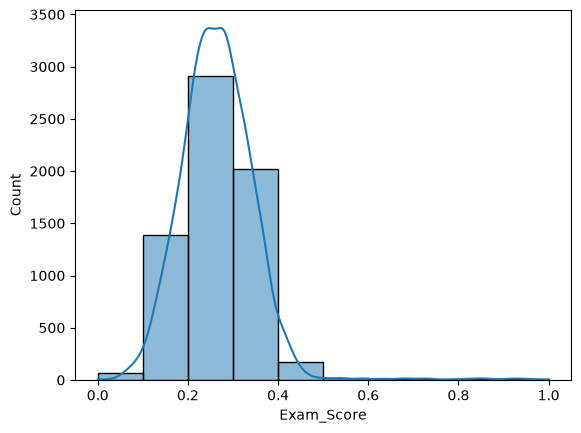

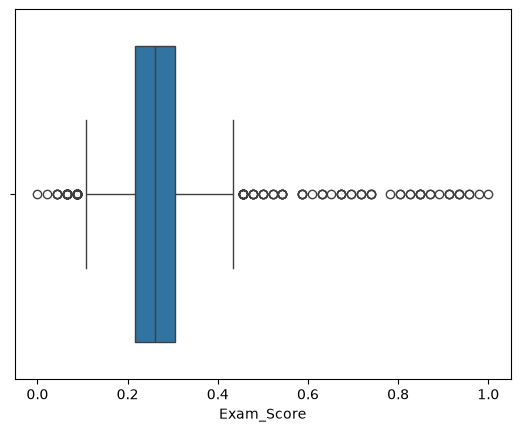

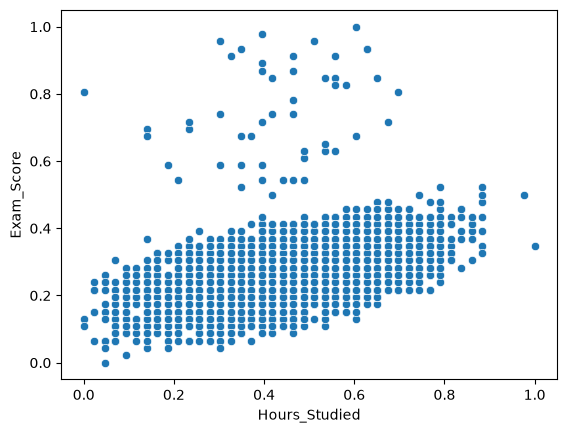

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Описова статистика
print(df.describe())

# Гістограма для кількісної змінної
sns.histplot(df['Exam_Score'], bins=10, kde=True)
plt.show()

# Коробкова діаграма
sns.boxplot(x=df['Exam_Score'])
plt.show()

# Діаграма розсіювання
sns.scatterplot(x=df['Hours_Studied'], y=df['Exam_Score'])
plt.show()

Побудова моделі

Перші 10 прогнозів:
[0.2274745  0.2400368  0.3200312  0.26350087 0.19924543 0.26826587
 0.34288156 0.3086782  0.32510305 0.30156679]
Середньоквадратична помилка (MSE): 0.0027
Коефіцієнт детермінації (R²): 0.5890


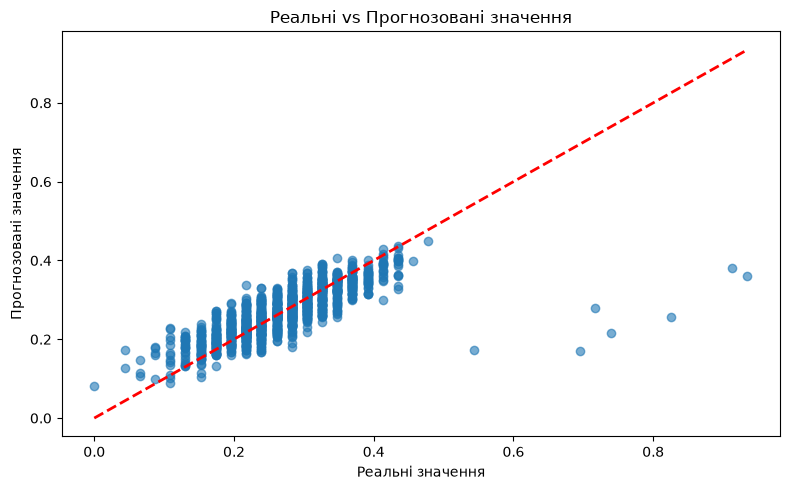

Трансформований датасет збережено у файл: transformed_dataset.csv
Графіки збережено: histogram.png, boxplot.png, correlation_heatmap.png,
scatterplot.png, predictions_vs_actual.png

Готово! Завантажте код і звіт на GitHub та опишіть висновки.


In [12]:
# Прогнозуємо підсумковий бал іспиту (Exam_Score)
FEATURE_1 = 'Hours_Studied'
FEATURE_2 = 'Attendance'
TARGET = 'Exam_Score'
 
X_train = train_set[[FEATURE_1, FEATURE_2]]
y_train = train_set[TARGET]
X_test = test_set[[FEATURE_1, FEATURE_2]]
y_test = test_set[TARGET]
 
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
 
print("Перші 10 прогнозів:")
print(predictions[:10])
 
# %%
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
print(f"Середньоквадратична помилка (MSE): {mse:.4f}")
print(f"Коефіцієнт детермінації (R²): {r2:.4f}")
 
# %%
# Порівняння реальних та прогнозованих значень
plt.figure(figsize=(8, 5))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2)
plt.xlabel('Реальні значення')
plt.ylabel('Прогнозовані значення')
plt.title('Реальні vs Прогнозовані значення')
plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()
 
# %% [markdown]
# ## Крок 8: Збереження результатів
 
# %%
df_transformed.to_csv('transformed_dataset.csv', index=False)
print("Трансформований датасет збережено у файл: transformed_dataset.csv")
print("Графіки збережено: histogram.png, boxplot.png, correlation_heatmap.png,")
print("scatterplot.png, predictions_vs_actual.png")
print("\nГотово! Завантажте код і звіт на GitHub та опишіть висновки.")

In [13]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(test_set[target], predictions)
r2 = r2_score(test_set[target], predictions)

print(f"MSE: {mse}")
print(f"R²: {r2}")

MSE: 0.002745329500975246
R²: 0.5890281259514627
